# Đồ án 3: Xích Markov  
## Bài toán 2

# Thông tin nhóm

| | Họ và tên | MSSV | Lớp |
|:---:|:---:|:---:|:---:|
| Thành viên 1 | Trần Kim Hữu | 24120059 | 24TNT1TN |
| Thành viên 2 | Nguyễn Danh Phương | 24120505 | 24TNT1TN |

## Mô tả bài toán

Có ba con rồng:

- Drogon: vị trí tại thời điểm $n$ là $X_n$.
- Rhaegal: vị trí tại thời điểm $n$ là $Y_n$.
- Viserion: vị trí tại thời điểm $n$ là $Z_n$.

Ba quá trình này là ba chuỗi Markov độc lập, có cùng ma trận chuyển và cùng phân phối dừng $s$.

Số vị trí có thể có là $M$, trong đó trạng thái 0 là nhà. Xác suất dừng tại nhà là $s_0$.

Theo quy ước của đề, ma trận chuyển trạng thái $P$ được nhân với vector phân phối cột:

$$
\pi_t = P\pi_{t-1}
$$

Vì vậy tổng từng **cột** của $P$ phải bằng 1.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

TOL = 1e-12

In [55]:
def assert_column_stochastic(P, tol=TOL):
    """
    Kiểm tra ma trận chuyển trạng thái theo quy ước cột.

    Args:
        P: Ma trận chuyển trạng thái cần kiểm tra.
        tol: Ngưỡng sai số khi kiểm tra phần tử âm và tổng cột.

    Returns:
        bool: True nếu P là ma trận xác suất hợp lệ.
    """
    P = np.asarray(P, dtype=float)

    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("P phải là ma trận vuông.")

    if np.any(P < -tol):
        raise ValueError("P có phần tử âm, không phải ma trận xác suất hợp lệ.")

    column_sums = P.sum(axis=0)
    if not np.allclose(column_sums, np.ones(P.shape[1]), atol=tol):
        raise ValueError("Tổng mỗi cột của P phải bằng 1.")

    return True


def solve_linear_system_gauss(A, b, tol=TOL):
    """
    Giải hệ tuyến tính Ax = b bằng khử Gauss với chọn trụ lớn nhất theo cột.

    Args:
        A: Ma trận hệ số vuông.
        b: Vector vế phải.
        tol (float): Ngưỡng xác định phần tử trụ gần bằng 0.

    Returns:
        np.ndarray: Vector nghiệm x của hệ Ax = b.
    """
    A = np.asarray(A, dtype=float).copy()
    b = np.asarray(b, dtype=float).copy()

    n = A.shape[0]
    if A.shape != (n, n) or b.shape[0] != n:
        raise ValueError("Kích thước A và b không phù hợp.")

    # Khử Gauss với chọn trụ lớn nhất theo cột
    for col in range(n):
        pivot_row = col + np.argmax(np.abs(A[col:, col]))

        if abs(A[pivot_row, col]) < tol:
            raise ValueError("Hệ tuyến tính suy biến.")

        if pivot_row != col:
            A[[col, pivot_row]] = A[[pivot_row, col]]
            b[[col, pivot_row]] = b[[pivot_row, col]]

        for row in range(col + 1, n):
            factor = A[row, col] / A[col, col]
            A[row, col:] -= factor * A[col, col:]
            b[row] -= factor * b[col]

    # Thế ngược để tìm nghiệm
    x = np.zeros(n, dtype=float)
    for row in range(n - 1, -1, -1):
        right_value = b[row] - np.dot(A[row, row + 1:], x[row + 1:])
        x[row] = right_value / A[row, row]

    return x


def stationary_distribution(P, tol=TOL):
    """
    Tìm một phân phối dừng pi của ma trận chuyển P.

    Args:
        P=: Ma trận chuyển trạng thái.
        tol (float): Ngưỡng sai số khi giải hệ và làm sạch nghiệm.

    Returns:
        tuple[bool, np.ndarray]: Cờ cho biết phân phối hợp lệ và vector phân phối dừng.
    """
    assert_column_stochastic(P)
    n = P.shape[0]

    A = P - np.eye(n)
    b = np.zeros(n)

    # Thay phương trình cuối bằng điều kiện tổng xác suất bằng 1
    A[-1, :] = np.ones(n)
    b[-1] = 1.0

    pi = solve_linear_system_gauss(A, b, tol)

    # Làm sạch sai số
    pi[np.abs(pi) < tol] = 0.0

    if abs(pi.sum()) > tol:
        pi = pi / pi.sum()

    exists = (
        np.all(pi >= -TOL)
        and np.allclose(pi.sum(), 1.0, atol=TOL)
        and np.allclose(P @ pi, pi, atol=TOL)
    )

    return exists, pi


def validate_distribution(prob, tol=TOL):
    """
    Kiểm tra một vector xác suất.

    Args:
        prob: Vector xác suất cần kiểm tra.
        tol (float): Ngưỡng sai số khi kiểm tra tổng xác suất.

    Returns:
        bool: True nếu prob là vector xác suất hợp lệ.
    """
    prob = np.asarray(prob, dtype=float)

    if prob.ndim != 1:
        raise ValueError("Phân phối phải là vector 1 chiều.")

    if np.any(prob < -tol):
        raise ValueError("Phân phối có xác suất âm.")

    if not np.allclose(prob.sum(), 1.0, atol=tol):
        raise ValueError("Tổng xác suất phải bằng 1.")

    return True

## Cấu hình ví dụ mô phỏng

Vì đề không cho ma trận chuyển cụ thể, phần mô phỏng chọn một ma trận chuyển hợp lệ để minh họa. Các hàm bên dưới vẫn được viết tổng quát cho mọi ma trận chuyển cột hợp lệ.

Ở ví dụ này, ta chọn ma trận chuyển đối xứng với $M=3$.

Theo quy ước cột, $P_{ij}=\Pr(X_{n+1}=i\mid X_n=j)$, tức là cột là trạng thái hiện tại và dòng là trạng thái kế tiếp. Ma trận chuyển ví dụ là:

$$
P=\begin{pmatrix}
0.50 & 0.25 & 0.25\\
0.25 & 0.50 & 0.25\\
0.25 & 0.25 & 0.50
\end{pmatrix}
$$

Vì ma trận này là song ngẫu nhiên theo quy ước cột, phân phối dừng là phân phối đều:

$$
s = \left(\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right)^T
$$

Trong đó:

$$
s_0 = \frac{1}{3}
$$

In [56]:
P_example = np.array([
    [0.50, 0.25, 0.25],
    [0.25, 0.50, 0.25],
    [0.25, 0.25, 0.50]
], dtype=float)

assert_column_stochastic(P_example)

stationary_exists, s_example = stationary_distribution(P_example)
if not stationary_exists:
    raise ValueError("Không tìm được phân phối dừng hợp lệ cho P_example.")

validate_distribution(s_example)

P_df = pd.DataFrame(
    P_example,
    index=[f"next={i}" for i in range(P_example.shape[0])],
    columns=[f"current={j}" for j in range(P_example.shape[0])]
)

s_df = pd.DataFrame(
    s_example,
    index=[f"state {i}" for i in range(P_example.shape[0])],
    columns=["stationary probability"]
)

s0 = s_example[0]

print("Ma trận chuyển ví dụ P:")
display(P_df)

print("Phân phối dừng s:")
display(s_df.round(12))

s0 = s_example[0]
print(f"s0 = {s0:.12f}")

Ma trận chuyển ví dụ P:


,current=0,current=1,current=2
next=0,0.50,0.25,0.25
next=1,0.25,0.50,0.25
next=2,0.25,0.25,0.50


Phân phối dừng s:


,stationary probability
state 0,0.333333
state 1,0.333333
state 2,0.333333


s0 = 0.333333333333


## Câu a:

Đặt biến chỉ báo:

$$
I_n =
\begin{cases}
1, & X_n = 0 \\
0, & X_n \ne 0
\end{cases}
$$

Số lần Drogon ở nhà trong các thời điểm $0,1,\ldots,24$ là:

$$
N = \sum_{n=0}^{24} I_n
$$

Vì Drogon bắt đầu theo phân phối dừng $s$, nên với mọi $n$:

$$
\Pr(X_n=0) = s_0
$$

Do đó:

$$
\mathbb{E}[N] = \sum_{n=0}^{24} \mathbb{E}[I_n]
= \sum_{n=0}^{24} \Pr(X_n=0)
= 25s_0
$$

In [57]:
def expected_drogon_home_count(s0, horizon=24):
    """
    Tính kỳ vọng số lần Drogon ở nhà từ thời điểm 0 đến horizon.

    Args:
        s0 (float): Xác suất dừng để Drogon ở nhà, tức trạng thái 0.
        horizon (int): Thời điểm cuối cùng được tính, bắt đầu từ 0.

    Returns:
        float: Kỳ vọng số lần Drogon ở nhà trong các thời điểm 0,...,horizon.
    """
    if s0 < 0 or s0 > 1:
        raise ValueError("s0 phải nằm trong [0, 1].")

    return (horizon + 1) * s0


theory_home_count = expected_drogon_home_count(s0, horizon=24)
print(f"Kỳ vọng lý thuyết số lần Drogon ở nhà từ 0 đến 24: {theory_home_count:.12f}")

Kỳ vọng lý thuyết số lần Drogon ở nhà từ 0 đến 24: 8.333333333333


## Câu b:

Xét vector vị trí của ba con rồng:

$$
V_n = (X_n,Y_n,Z_n)
$$

Vì $X_n,Y_n,Z_n$ là các chuỗi Markov độc lập và có cùng ma trận chuyển $P$, nên:

$$
\Pr(V_{n+1}=(a',b',c') \mid V_n=(a,b,c), \text{quá khứ})
=
P_{a',a}P_{b',b}P_{c',c}
$$

Biểu thức này chỉ phụ thuộc vào trạng thái hiện tại $(a,b,c)$, không phụ thuộc vào toàn bộ quá khứ. Vì vậy $V_n$ là một chuỗi Markov.

Ma trận chuyển của chuỗi chung được xác định bởi:

$$
P^{(3)}_{(a',b',c'),(a,b,c)} = P_{a',a}P_{b',b}P_{c',c}.
$$

Tương đương, có thể viết:

$$
P^{(3)} = P \otimes P \otimes P.
$$

Dãy $W_n$ là cách mã hóa một-một vector $(X_n,Y_n,Z_n)$ thành một số từ $1$ đến $M^3$, nên $W_n$ cũng là một chuỗi Markov.

Trong code, ta dùng mã 0-based để thuận tiện với chỉ số mảng Python, tức là mã chạy từ $0$ đến $M^3-1$. Mã hóa đúng theo đề là $W_n=\text{code}+1$, nên tính Markov không thay đổi vì đây vẫn là ánh xạ một-một.

In [58]:
def encode_state(x, y, z, M):
    """
    Mã hóa bộ ba trạng thái (x, y, z) thành chỉ số 0-based.

    Args:
        x (int): Trạng thái của con rồng thứ nhất.
        y (int): Trạng thái của con rồng thứ hai.
        z (int): Trạng thái của con rồng thứ ba.
        M (int): Số trạng thái của mỗi chuỗi Markov đơn.

    Returns:
        int: Chỉ số 0-based biểu diễn bộ ba trạng thái.
    """
    return x * M * M + y * M + z


def decode_state(code, M):
    """
    Giải mã chỉ số 0-based thành bộ ba trạng thái (x, y, z).

    Args:
        code (int): Chỉ số 0-based cần giải mã.
        M (int): Số trạng thái của mỗi chuỗi Markov đơn.

    Returns:
        tuple[int, int, int]: Bộ ba trạng thái (x, y, z).
    """
    x = code // (M * M)
    remainder = code % (M * M)
    y = remainder // M
    z = remainder % M
    return x, y, z


def build_joint_transition_matrix(P):
    """
    Xây dựng ma trận chuyển cho chuỗi Markov W_n biểu diễn vector (X_n, Y_n, Z_n).

    Args:
        P: Ma trận chuyển trạng thái của một con rồng.

    Returns:
        np.ndarray: Ma trận chuyển trạng thái chung kích thước M^3 x M^3.
    """
    assert_column_stochastic(P)

    M = P.shape[0]
    total_states = M ** 3
    P_joint = np.zeros((total_states, total_states), dtype=float)

    for current_code in range(total_states):
        x, y, z = decode_state(current_code, M)

        for x_next in range(M):
            for y_next in range(M):
                for z_next in range(M):
                    next_code = encode_state(x_next, y_next, z_next, M)
                    P_joint[next_code, current_code] = (
                        P[x_next, x] * P[y_next, y] * P[z_next, z]
                    )

    assert_column_stochastic(P_joint)
    return P_joint


P_joint_example = build_joint_transition_matrix(P_example)

print("Kích thước ma trận chuyển của W_n:", P_joint_example.shape)
if np.allclose(P_joint_example.sum(axis=0), 1.0):
    print("Ma trận chuyển của W_n hợp lệ.")
else:
    raise ValueError("Ma trận chuyển của W_n không hợp lệ.")

Kích thước ma trận chuyển của W_n: (27, 27)
Ma trận chuyển của W_n hợp lệ.


## Câu c:

Biết cả ba con bắt đầu ở nhà tại thời điểm 0:

$$
(X_0,Y_0,Z_0) = (0,0,0)
$$

Phân phối dừng của từng con rồng là $s$. Vì ba chuỗi độc lập, phân phối dừng của vector chung là tích:

$$
s \otimes s \otimes s
$$

Do đó xác suất dừng của trạng thái chung $(0,0,0)$ là:

$$
s_0^3
$$

Vì yêu cầu là trở về nhà lần nữa, ta không tính thời điểm ban đầu $n=0$. Gọi:

$$
T^+_{(0,0,0)} = \min\{n \ge 1 : (X_n,Y_n,Z_n)=(0,0,0)\}.
$$

Với điều kiện $s_0>0$ và trạng thái chung $(0,0,0)$ là trạng thái hồi quy dương trong xích hữu hạn, theo công thức thời gian quay lại trung bình:

$$
\mathbb{E}[T^+_{(0,0,0)}] = \frac{1}{s_0^3}
$$

In [59]:
def expected_joint_return_time(s0):
    """
    Tính thời gian kỳ vọng để cả ba con rồng cùng trở về nhà lần nữa, biết cả ba bắt đầu ở nhà tại thời điểm 0.

    Args:
        s0 (float): Xác suất dừng để một con rồng ở nhà, tức trạng thái 0.

    Returns:
        float: Thời gian quay lại kỳ vọng của trạng thái chung (0, 0, 0).
    """
    if s0 <= 0:
        raise ValueError("s0 phải dương để thời gian quay lại kỳ vọng hữu hạn.")

    return 1.0 / (s0 ** 3)


theory_joint_return_time = expected_joint_return_time(s0)
print(f"Thời gian kỳ vọng lý thuyết để cả ba cùng trở về nhà: {theory_joint_return_time:.12f}")

Thời gian kỳ vọng lý thuyết để cả ba cùng trở về nhà: 27.000000000000


## Câu d:

Ta mô phỏng nhiều lần độc lập.

Cần ước lượng hai đại lượng:

1. Số lần trung bình Drogon ở nhà trong các thời điểm $0,1,\ldots,24$.
2. Thời gian trung bình để cả ba con rồng cùng trở về nhà lần nữa tại cùng một thời điểm.

Sau đó so sánh với công thức lý thuyết:

$$
25s_0
$$

và:

$$
\frac{1}{s_0^3}
$$

In [60]:
def sample_from_distribution(prob, rng):
    """
    Sinh ngẫu nhiên một trạng thái theo vector xác suất prob.

    Args:
        prob (array-like): Vector xác suất dùng để lấy mẫu.
        rng (np.random.Generator): Bộ sinh số ngẫu nhiên.

    Returns:
        int: Chỉ số trạng thái được lấy mẫu.
    """
    prob = np.asarray(prob, dtype=float)
    prob = prob / prob.sum()

    cumulative = np.cumsum(prob)
    u = rng.random()

    return int(np.searchsorted(cumulative, u, side="right"))


def next_state(P, current_state, rng):
    """
    Sinh trạng thái kế tiếp của một chuỗi Markov từ trạng thái hiện tại.

    Args:
        P: Ma trận chuyển trạng thái theo quy ước cột.
        current_state (int): Trạng thái hiện tại của chuỗi Markov.
        rng (np.random.Generator): Bộ sinh số ngẫu nhiên.

    Returns:
        int: Trạng thái kế tiếp được lấy mẫu.
    """
    return sample_from_distribution(P[:, current_state], rng)


def simulate_markov_chain(P, initial_state, steps, rng):
    """
    Sinh một chuỗi Markov có độ dài steps + 1.

    Args:
        P: Ma trận chuyển trạng thái theo quy ước cột.
        initial_state (int): Trạng thái ban đầu của chuỗi Markov.
        steps (int): Số bước chuyển trạng thái cần mô phỏng.
        rng (np.random.Generator): Bộ sinh số ngẫu nhiên.

    Returns:
        np.ndarray: Mảng trạng thái từ states[0] đến states[steps].
    """
    assert_column_stochastic(P)

    states = np.empty(steps + 1, dtype=int)
    states[0] = initial_state

    for t in range(1, steps + 1):
        states[t] = next_state(P, states[t - 1], rng)

    return states


def estimate_drogon_home_count(P, s, horizon=24, num_trials=20000, seed=2026):
    """
    Ước lượng số lần trung bình Drogon ở nhà trong các thời điểm 0,...,horizon.

    Args:
        P: Ma trận chuyển trạng thái theo quy ước cột.
        s: Phân phối dừng dùng để sinh trạng thái ban đầu.
        horizon (int): Thời điểm cuối cùng được tính, bắt đầu từ 0.
        num_trials (int): Số lần mô phỏng Monte Carlo.
        seed (int): Seed cho bộ sinh số ngẫu nhiên.

    Returns:
        tuple[float, float]: Giá trị trung bình ước lượng và sai số chuẩn.
    """
    assert_column_stochastic(P)
    validate_distribution(s)

    rng = np.random.default_rng(seed)
    counts = np.empty(num_trials, dtype=float)

    for trial in range(num_trials):
        initial_state = sample_from_distribution(s, rng)
        chain = simulate_markov_chain(P, initial_state, horizon, rng)
        counts[trial] = np.sum(chain == 0)

    mean_estimate = counts.mean()
    standard_error = counts.std(ddof=1) / np.sqrt(num_trials)

    return mean_estimate, standard_error


def estimate_joint_return_time(P, num_trials=20000, max_steps=10000, seed=2026):
    """
    Ước lượng thời gian trung bình để cả ba con rồng cùng trở về nhà lần nữa.

    Args:
        P: Ma trận chuyển trạng thái theo quy ước cột.
        num_trials (int): Số lần mô phỏng Monte Carlo.
        max_steps (int): Số bước tối đa cho mỗi lần mô phỏng.
        seed (int): Seed cho bộ sinh số ngẫu nhiên.

    Returns:
        tuple[float, float, float, int]: Thời gian trung bình ước lượng, sai số chuẩn, tỷ lệ thành công và số lần không quay lại.
    """
    assert_column_stochastic(P)

    rng = np.random.default_rng(seed)
    return_times = []
    missed = 0

    for trial in range(num_trials):
        x = 0
        y = 0
        z = 0

        returned = False

        for t in range(1, max_steps + 1):
            x = next_state(P, x, rng)
            y = next_state(P, y, rng)
            z = next_state(P, z, rng)

            if x == 0 and y == 0 and z == 0:
                return_times.append(t)
                returned = True
                break

        if not returned:
            missed += 1

    return_times = np.asarray(return_times, dtype=float)

    if len(return_times) == 0:
        raise ValueError("Không có lần mô phỏng nào quay lại trong max_steps.")

    mean_estimate = return_times.mean()
    standard_error = return_times.std(ddof=1) / np.sqrt(len(return_times))
    success_rate = len(return_times) / num_trials

    return mean_estimate, standard_error, success_rate, missed

In [61]:
num_trials = 20000

sim_home_count, se_home_count = estimate_drogon_home_count(
    P_example,
    s_example,
    horizon=24,
    num_trials=num_trials,
    seed=2026
)

sim_joint_return, se_joint_return, success_rate, missed = estimate_joint_return_time(
    P_example,
    num_trials=num_trials,
    max_steps=10000,
    seed=2026
)

comparison_df = pd.DataFrame({
    "Đại lượng": [
        "Số lần Drogon ở nhà từ 0 đến 24",
        "Thời gian để cả ba cùng trở về nhà"
    ],
    "Lý thuyết": [
        theory_home_count,
        theory_joint_return_time
    ],
    "Mô phỏng": [
        sim_home_count,
        sim_joint_return
    ],
    "Sai số chuẩn mô phỏng": [
        se_home_count,
        se_joint_return
    ]
})

display(comparison_df.round(6))

print(f"Số lần mô phỏng: {num_trials}")
print(f"Tỷ lệ mô phỏng tìm được thời điểm cả ba cùng trở về nhà: {success_rate:.6f}")
print(f"Số lần không quay lại trong max_steps: {missed}")

,Đại lượng,Lý thuyết,Mô phỏng,Sai số chuẩn mô phỏng
0,Số lần Drogon ở nhà từ 0 đến 24,8.333333,8.38180,0.021335
1,Thời gian để cả ba cùng trở về nhà,27.000000,26.85995,0.204640


Số lần mô phỏng: 20000
Tỷ lệ mô phỏng tìm được thời điểm cả ba cùng trở về nhà: 1.000000
Số lần không quay lại trong max_steps: 0


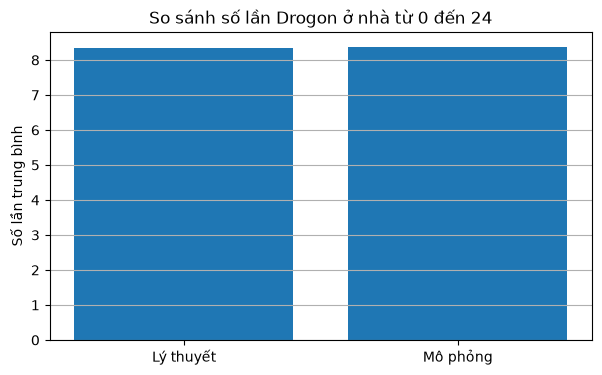

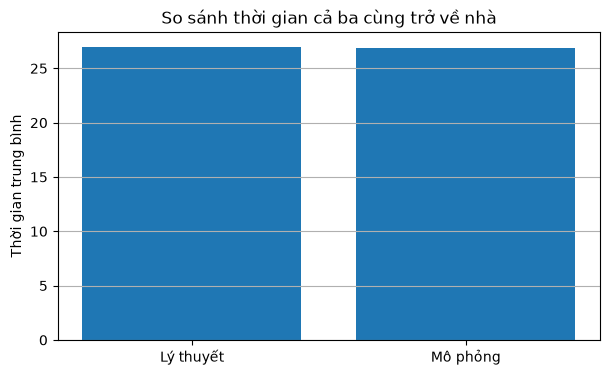

In [62]:
plt.figure(figsize=(7, 4))
plt.bar(["Lý thuyết", "Mô phỏng"], [theory_home_count, sim_home_count])
plt.ylabel("Số lần trung bình")
plt.title("So sánh số lần Drogon ở nhà từ 0 đến 24")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(["Lý thuyết", "Mô phỏng"], [theory_joint_return_time, sim_joint_return])
plt.ylabel("Thời gian trung bình")
plt.title("So sánh thời gian cả ba cùng trở về nhà")
plt.grid(axis="y")
plt.show()

Kết quả mô phỏng gần với công thức lý thuyết. Sai lệch nhỏ là do sai số Monte Carlo. Khi tăng số lần mô phỏng, giá trị trung bình mô phỏng có xu hướng tiến gần hơn đến giá trị lý thuyết.

,Số lần mô phỏng,Mô phỏng,Lý thuyết,Sai số tuyệt đối,Sai số chuẩn mô phỏng
0,100,8.0600,8.333333,0.273333,0.255770
1,500,8.1320,8.333333,0.201333,0.134883
2,1000,8.3760,8.333333,0.042667,0.100043
3,5000,8.4544,8.333333,0.121067,0.042198
4,10000,8.4114,8.333333,0.078067,0.030200
5,20000,8.3818,8.333333,0.048467,0.021335


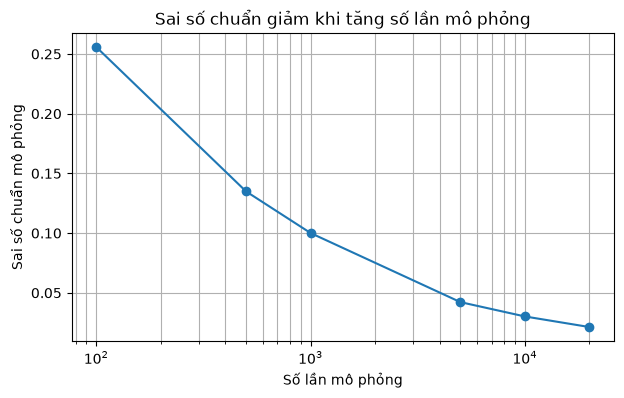

In [63]:
trial_sizes = [100, 500, 1000, 5000, 10000, 20000]
error_records = []

for trial_count in trial_sizes:
    mean_estimate, standard_error = estimate_drogon_home_count(
        P_example,
        s_example,
        horizon=24,
        num_trials=trial_count,
        seed=2026
    )

    absolute_error = abs(mean_estimate - theory_home_count)
    error_records.append([
        trial_count,
        mean_estimate,
        theory_home_count,
        absolute_error,
        standard_error
    ])

error_by_trials_df = pd.DataFrame(
    error_records,
    columns=[
        "Số lần mô phỏng",
        "Mô phỏng",
        "Lý thuyết",
        "Sai số tuyệt đối",
        "Sai số chuẩn mô phỏng"
    ]
)

display(error_by_trials_df.round(6))

plt.figure(figsize=(7, 4))
plt.plot(
    error_by_trials_df["Số lần mô phỏng"],
    error_by_trials_df["Sai số chuẩn mô phỏng"],
    marker="o"
)
plt.xscale("log")
plt.xlabel("Số lần mô phỏng")
plt.ylabel("Sai số chuẩn mô phỏng")
plt.title("Sai số chuẩn giảm khi tăng số lần mô phỏng")
plt.grid(True, which="both")
plt.show()